## Import packages

In [ ]:


import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report,recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

## Data preprocessing

In [8]:
# load data
data = pd.read_csv('data/df_merged.csv')

In [105]:
# remove rows with offer_id as na (transactions)
data_offers = data.loc[data['offer_id'].isna()==False]

# add membership_length column
data_offers['membership_days'] = (pd.to_datetime('2019-01-01') - pd.to_datetime(data_offers['became_member_on'])).dt.days
# remove rows where both offer_received and offer_viewed are False
data_offers = data_offers.loc[~((data_offers['offer_received']==False) & (data_offers['offer_viewed']==False))]
data_offers= data_offers.loc[data_offers['O']==False]
# drop useless columns in the model
columns_to_remove = ['time','amount','offer_completed','transaction','valid','O']
data_offers= data_offers.drop(
  columns = columns_to_remove,
  axis=1
)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_7893/832611501.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_offers['membership_days'] = (pd.to_datetime('2019-01-01') - pd.to_datetime(data_offers['became_member_on'])).dt.days


In [106]:
# group offer_received and offer_viewed by customer_id & offer_id
metrics_columns = ['offer_received','offer_viewed']
group_columns = list(set(data_offers.columns) - set(metrics_columns))
data_offers = data_offers.groupby(
  by=group_columns
).agg(
  offer_received=('offer_received', 'sum'),
  offer_viewed=('offer_viewed', 'sum')
).reset_index()

# convert to 0/1
data_offers[['F','M']] = data_offers[['F','M']].astype(int)

# get dummies for difficulty, reward, offer_type, duration, offer_id
columns = ['offer_type','offer_id','duration','reward','difficulty']
data_offers = pd.get_dummies(
  data = data_offers,
  columns = columns,
  dtype=int
)

In [107]:
# rescale income, membership_days, age
data_offers_recaled = data_offers.copy()
scaler = MinMaxScaler()
data_offers_recaled[['income','membership_days','age']]=scaler.fit_transform(
  data_offers[['income','membership_days','age']]
)

In [108]:
data_offers_recaled.loc[data_offers_recaled['customer_id']=='78afa995795e4d85b5d9ceeca43f5fef']

,income,email,social,age,mobile,customer_id,membership_days,became_member_on,F,web,...,reward_0.0,reward_2.0,reward_3.0,reward_5.0,reward_10.0,difficulty_0.0,difficulty_5.0,difficulty_7.0,difficulty_10.0,difficulty_20.0
50395,0.777778,1.0,1.0,0.686747,1.0,78afa995795e4d85b5d9ceeca43f5fef,0.243006,2017-05-09,1,0.0,...,0,0,0,0,1,0,0,0,1,0
50464,0.777778,1.0,0.0,0.686747,1.0,78afa995795e4d85b5d9ceeca43f5fef,0.243006,2017-05-09,1,1.0,...,0,0,0,1,0,0,1,0,0,0
50495,0.777778,1.0,1.0,0.686747,1.0,78afa995795e4d85b5d9ceeca43f5fef,0.243006,2017-05-09,1,1.0,...,0,0,0,1,0,0,1,0,0,0
50688,0.777778,1.0,1.0,0.686747,1.0,78afa995795e4d85b5d9ceeca43f5fef,0.243006,2017-05-09,1,0.0,...,1,0,0,0,0,1,0,0,0,0


In [167]:
# change offer_viewed=2 to 1
data_offers_recaled.loc[data_offers_recaled['offer_viewed']>1, 'offer_viewed']=1

## Correlations

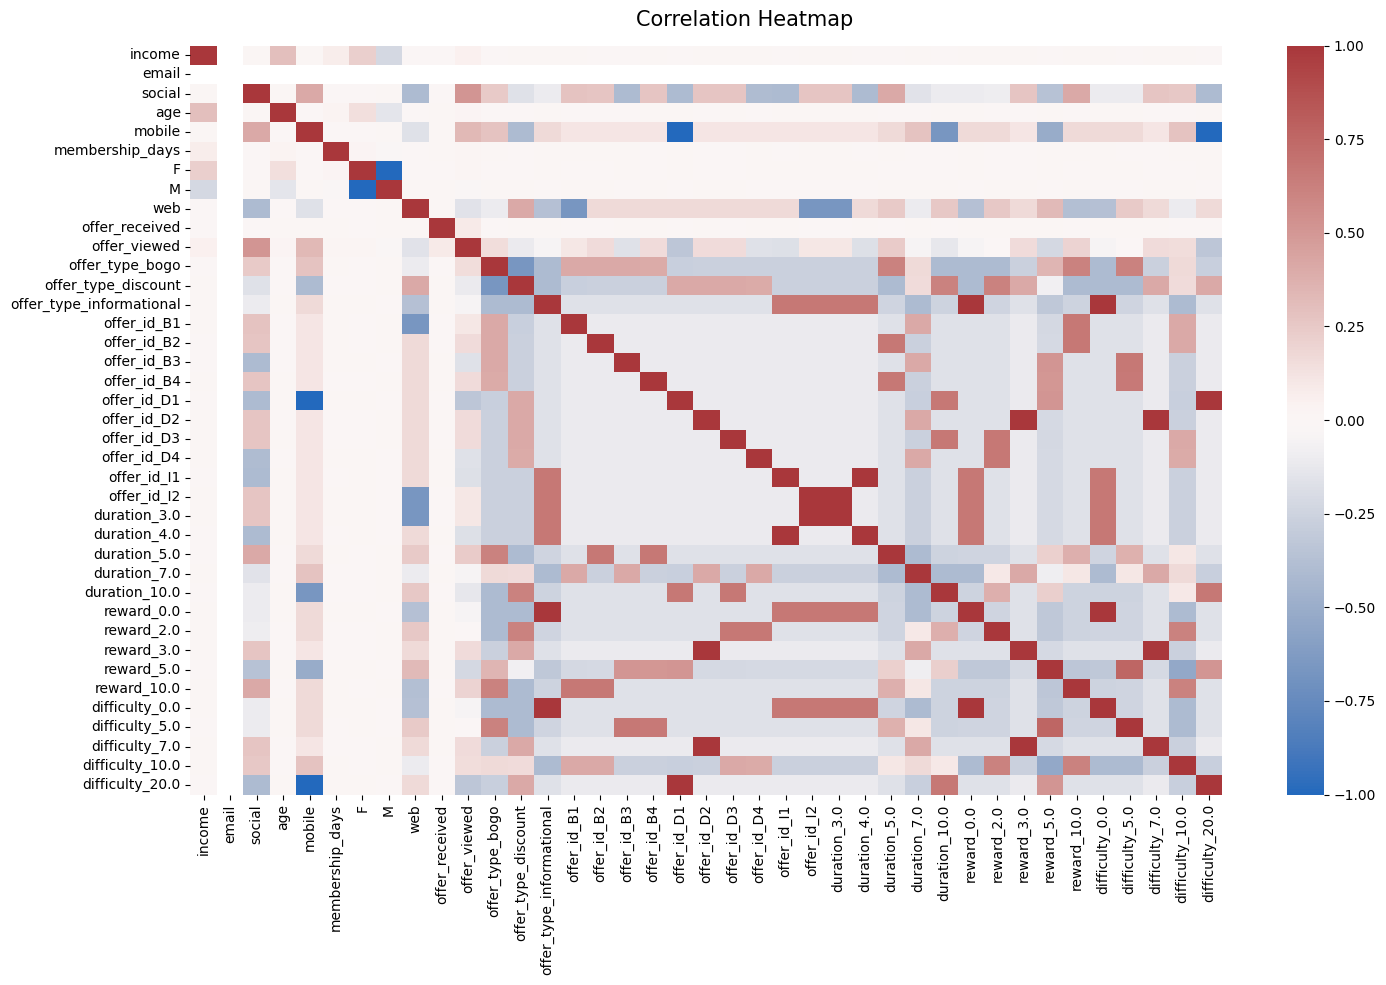

In [171]:
cor_columns = ['income','email','social','age','mobile','membership_days','F','M','web','offer_received','offer_viewed',
               'offer_type_bogo', 'offer_type_discount', 'offer_type_informational', 'offer_id_B1',
       'offer_id_B2', 'offer_id_B3', 'offer_id_B4', 'offer_id_D1',
       'offer_id_D2', 'offer_id_D3', 'offer_id_D4', 'offer_id_I1',
       'offer_id_I2', 'duration_3.0', 'duration_4.0', 'duration_5.0',
       'duration_7.0', 'duration_10.0', 'reward_0.0', 'reward_2.0',
       'reward_3.0', 'reward_5.0', 'reward_10.0', 'difficulty_0.0',
       'difficulty_5.0', 'difficulty_7.0', 'difficulty_10.0',
       'difficulty_20.0']
corr = data_offers_recaled[cor_columns].corr(
  method='spearman'
)

# plot the correlation heatmap
fit, ax = plt.subplots(figsize=(15,10))
sns.heatmap(
  data = corr,
  cmap='vlag',
  ax=ax
  )
plt.suptitle('Correlation Heatmap',fontsize=15)
plt.tight_layout()
plt.savefig('images/model/correlation_heatmap.png', bbox_inches='tight')
plt.show()

The correlation heatmap shows that the offer_received does not have a strong correlation with any of the feature columns

## Random Forest

### Model

In [232]:
# train test data
X = data_offers_recaled.drop(columns = ['offer_received','offer_viewed','customer_id','became_member_on'])
y = data_offers_recaled['offer_viewed']
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.3,
  random_state=42
)

In [233]:
# define random forest model
rf = RandomForestClassifier(
  random_state=42,
  n_jobs=-1
)

In [234]:
# define hyperparameter grid
param_grid = {
  'max_depth': [5,10,20],
  'min_samples_split': [2,5,10],
  'max_features': ['sqrt','log2']
}

In [235]:
# hyperparameter tunning + cv
grid_search_cv = GridSearchCV(
  estimator=rf,
  param_grid=param_grid,
  cv=5,
  scoring='roc_auc',
  n_jobs=-1,
  verbose=1
)
# fit random forest
grid_search_cv.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [236]:
# best model/parameters/score
print('best model:', grid_search_cv.best_estimator_)
print('best parameters:', grid_search_cv.best_params_)
print('best score:', grid_search_cv.best_score_)
best_rf = grid_search_cv.best_estimator_

best model: RandomForestClassifier(max_depth=10, min_samples_split=5, n_jobs=-1,
                       random_state=42)
best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5}
best score: 0.861327525240041


### Accuracy

In [194]:
# fit with best rf model
y_test_pred = best_rf.predict(X_test)
y_test_prob = best_rf.predict_proba(X_test)[:,1]

# evaluation
scores = []
accuracy_scores = accuracy_score(y_test, y_test_pred)
recall_scores = recall_score(y_test, y_test_pred)
precision_scores = precision_score(y_test, y_test_pred)
roc_auc_scores = roc_auc_score(y_test, y_test_prob)
scores.append({
  'accuracy score': accuracy_scores,
  'recall score': recall_scores,
  'precision score': precision_scores,
  'roc auc score': roc_auc_scores
})
scores

[{'accuracy score': 0.8216209598432909,
  'recall score': 0.9172275641025641,
  'precision score': 0.8588685474189676,
  'roc auc score': 0.864260628208453}]

In [205]:
# classification report
print(classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.66      0.51      0.58      3856
           1       0.86      0.92      0.89     12480

    accuracy                           0.82     16336
   macro avg       0.76      0.71      0.73     16336
weighted avg       0.81      0.82      0.81     16336



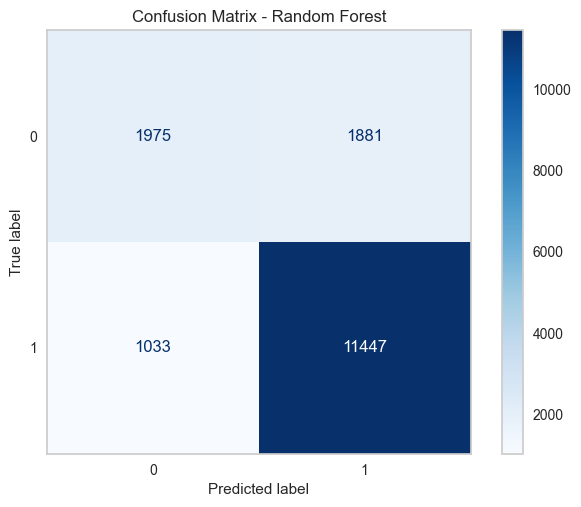

In [230]:
# display confusion matrix
plt.rcParams['axes.grid'] = False
ConfusionMatrixDisplay.from_predictions(
  y_test,
  y_test_pred,
  cmap='Blues'
)
plt.title('Confusion Matrix - Random Forest')
plt.savefig('images/model/confusion_matrix_rf.png')

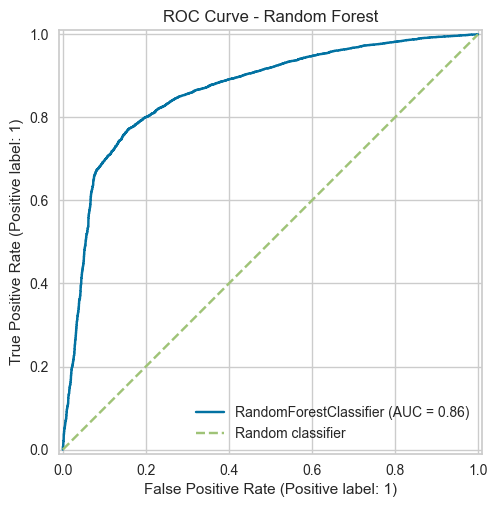

In [224]:
# roc auc curve
fig, ax = plt.subplots()

RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier'
)

ax.set_title("ROC Curve - Random Forest")
ax.legend()
plt.savefig('images/model/auc_roc_curve.png')
plt.show()

### Feature importance

In [ ]:
rf_feature_importance = pd.DataFrame({
  'features': X.columns,
  'feature_importance': best_rf.feature_importances_
  }).sort_values(by = 'feature_importance', ascending=False).reset_index(drop=True)

# top features that explain 85% of the variantions
rf_feature_importance_85 = rf_feature_importance.loc[rf_feature_importance['feature_importance'].cumsum()<=0.85]

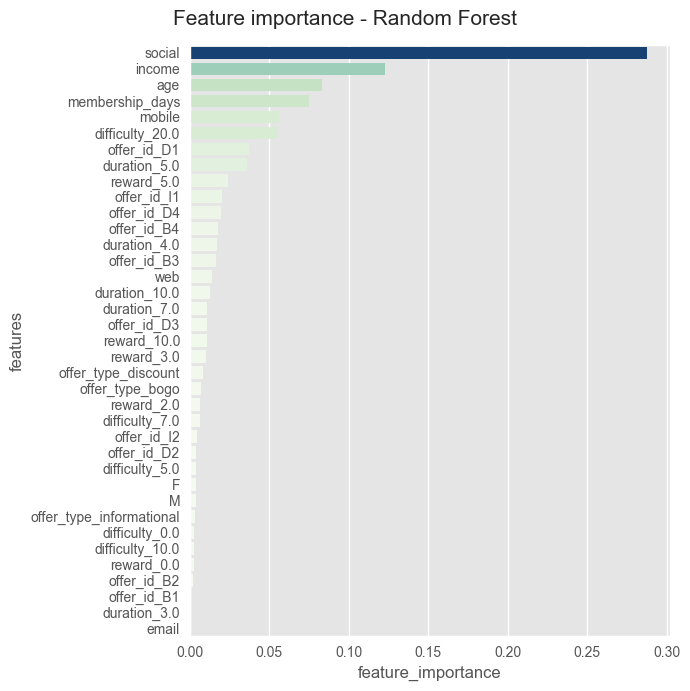

In [293]:
# plot the feature importance
plt.style.use('ggplot')
fig, axes = plt.subplots(figsize=(7,7))
sns.barplot(
    data=rf_feature_importance,
    x='feature_importance',
    y='features',
    hue='feature_importance',
    palette='GnBu',
    legend=False
)
plt.suptitle('Feature importance - Random Forest', fontsize=15)
plt.tight_layout()
plt.savefig('images/model/feature_importance_rf.png')

## Logistic model

### Model

In [302]:
# model
lr = LogisticRegression(
 max_iter = 1000
)

# para grid
param_grid = {
  'l1_ratio': [0, 1],
  'C': [0.01, 0.1, 1, 10, 100],
  'solver': ['saga','liblinear']
}

# grid search
grid_search_cv = GridSearchCV(
  estimator = lr,
  param_grid = param_grid,
  cv = 5,
  n_jobs= -1,
  scoring = 'roc_auc'
)

# fit logistic odel
grid_search_cv.fit(X_train, y_train)

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'l1_ratio': [0, 1], 'solver': ['saga', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [303]:
# best model
print('Best estimators:', grid_search_cv.best_estimator_)
print('Best parameters:', grid_search_cv.best_params_)
print('Best score:', grid_search_cv.best_score_)

Best estimators: LogisticRegression(C=0.1, l1_ratio=1, max_iter=1000, solver='liblinear')
Best parameters: {'C': 0.1, 'l1_ratio': 1, 'solver': 'liblinear'}
Best score: 0.8389344461807411


In [353]:
# coefficients
pd.DataFrame({
  'features': X_train.columns,
  'coef': grid_search_cv.best_estimator_.coef_[0]
}).sort_values(
  by = 'coef',
  key = lambda x: x.abs(),
  ascending = False
  )

,features,coef
2,social,2.145903
24,duration_5.0,0.893923
16,offer_id_D1,-0.885088
18,offer_id_D3,0.847619
17,offer_id_D2,0.618682
0,income,0.333371
3,age,0.287224
29,reward_3.0,0.261548
5,membership_days,0.205702
25,duration_7.0,-0.134062


### Accuracy

In [319]:
best_lr = grid_search_cv.best_estimator_
y_test_pred = best_lr.predict(X_test)
y_test_prob = best_lr.predict_proba(X_test)[:,1]

lr_scores = []
lr_accuracy_scores = accuracy_score(y_test, y_test_pred)
lr_f1_scores = f1_score(y_test, y_test_pred)
lr_recall_scores = recall_score(y_test, y_test_pred)
lr_precision_scores = precision_score(y_test, y_test_pred)
lr_roc_auc_scores = roc_auc_score(y_test, y_test_pred)

lr_scores.append(
  {
    'accuracy score': lr_accuracy_scores,
    'f1 score': lr_f1_scores,
    'roc auc score' : lr_roc_auc_scores,
    'precision score': lr_precision_scores,
    'recall score': lr_recall_scores
  }
)

lr_scores


[{'accuracy score': 0.799400097943193,
  'f1 score': 0.8785801622883397,
  'roc auc score': 0.6309906639004149,
  'precision score': 0.8171479771176511,
  'recall score': 0.95}]

In [306]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.66      0.31      0.42      3856
           1       0.82      0.95      0.88     12480

    accuracy                           0.80     16336
   macro avg       0.74      0.63      0.65     16336
weighted avg       0.78      0.80      0.77     16336



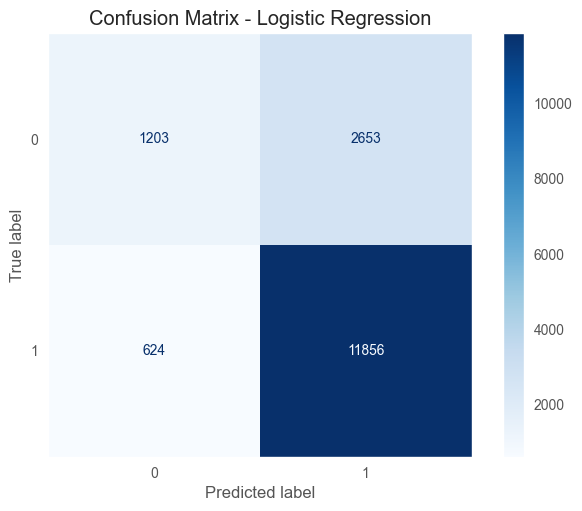

In [313]:
# display confusion matrix
plt.rcParams['axes.grid']=False
ConfusionMatrixDisplay.from_predictions(
  y_test,
  y_test_pred,
  cmap='Blues'
)
plt.title('Confusion Matrix - Logistic Regression')

plt.savefig('images/model/confusion_matrix_lr.png')

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


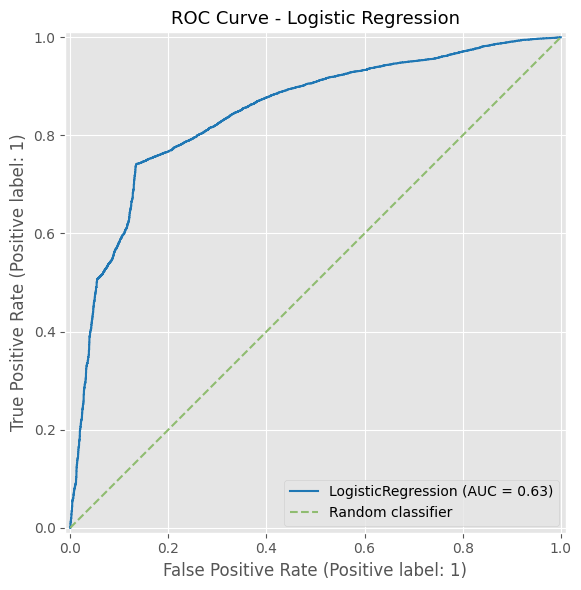

In [337]:
# auc roc curve
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    color="tab:blue",
    ax=ax,
    label = f'LogisticRegression (AUC = {lr_roc_auc_scores:.2f})'
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#8FBC70",
    label="Random classifier"
)

ax.set_title("ROC Curve - Logistic Regression", fontsize=13)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig('images/model/auc_roc_curve_lr.png')

### Feature importance

In [ ]:
lr_feature_importance = pd.DataFrame({
  'features': X_train.columns,
  'feature importance': best_rf.feature_importances_
}).sort_values(
  by = 'feature importance',
  ascending=False
).reset_index(drop=True)


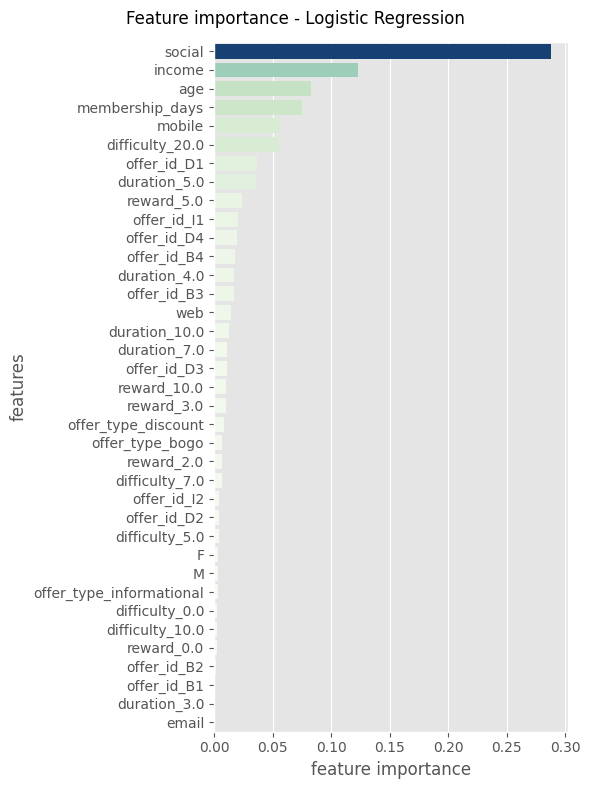

In [386]:
fig, ax = plt.subplots(figsize = (6,8))
sns.barplot(
  data = lr_feature_importance,
  x = 'feature importance',
  y = 'features',
  hue = 'feature importance',
  palette = 'GnBu',
  legend = False,
  ax = ax
)
plt.suptitle('Feature importance - Logistic Regression')
plt.tight_layout()
plt.savefig('images/model/feature_importance_lr.png')

## Random Forest, Logistic, KNN, XGBoost, SVC

### Model

In [ ]:
# define the model build
def classification_model(model, param_grid, X_train, y_train):
  grid_search_cv = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    scoring = 'roc_auc',
    n_jobs = -1,
    cv = 5,
    verbose = 1
  )
  grid_search_cv.fit(X_train, y_train)

  return grid_search_cv

# build models list
models = [
  KNeighborsClassifier(),
  SVC(),
  XGBClassifier(random_state=42),
  RandomForestClassifier(
  random_state=42,
  n_jobs=-1),
  LogisticRegression(max_iter = 1000)
]

# build grid_params list
param_grids = [
  {
    'n_neighbors': [1,5,10,20,30,50], # how many neighbors to check to decide the class
    'weights': ['uniform','distance'], # weight of each neighbor
    'metric': ['euclidean','manhattan'] # distance formula
  },
  {
    'C': [0.01, 0.1, 1, 10], # penalty (small value is high penalty)
    'kernel': ['linear','rbf'], # linear or non-linear svc
    'gamma': ['auto'] # decide the size of zone of influence of each obs
  },
  {
    'max_depth': [3, 5, 7], # depth of trees
    'colsample_bytree': [0.3, 0.5, 0.8, 1], # features use
    'subsample': [0.5, 0.8, 1], # observations to use
    'n_estimators': [100, 200, 300], # number of trees
    'learning_rate': [0.1, 0.3, 0.5, 0.8] # how much each tree contributes to the overall model
  },
  {
  'max_depth': [5,10,20],
  'min_samples_split': [5,10],
  'max_features': ['sqrt','log2']
  },
  {
  'l1_ratio': [0, 1],
  'C': [0.01, 0.1, 1, 10],
  'solver': ['saga','liblinear']
  }
]

In [ ]:
# train the model
results = []
for model, param_grid in zip(models, param_grids):
  print(f'Training {model.__class__.__name__} model...')
  model_output = classification_model(model, param_grid, X_train, y_train)
  best_model = model_output.best_estimator_
  print('Best model:', best_model)
  best_params = model_output.best_params_
  print('Best parameters:', best_params)
  best_score = model_output.best_score_
  print('Best score:', best_score)
  results.append({
    'model': model.__class__.__name__,
    'best_model': best_model,
    'best_params': best_params,
    'best_score': best_score
  })

Training RandomForestClassifier model...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best model: RandomForestClassifier(max_depth=10, min_samples_split=5, n_jobs=-1,
                       random_state=42)
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5}
Best score: 0.861327525240041
Training LogisticRegression model...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best model: LogisticRegression(C=0.1, l1_ratio=1, max_iter=1000, solver='liblinear')
Best parameters: {'C': 0.1, 'l1_ratio': 1, 'solver': 'liblinear'}
Best score: 0.8389313530446956


In [574]:
results_copy

[{'model': 'KNeighborsClassifier',
  'best_model': KNeighborsClassifier(metric='manhattan', n_neighbors=50),
  'best_params': {'metric': 'manhattan',
   'n_neighbors': 50,
   'weights': 'uniform'},
  'best_score': 0.8569280165619532},
 {'model': 'SVC',
  'best_model': SVC(C=100, kernel='linear'),
  'best_params': {'C': 100, 'gamma': 'scale', 'kernel': 'linear'},
  'best_score': 0.8337526033783208},
 {'model': 'XGBClassifier',
  'best_model': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.8, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=0.1, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, m

### Accuracy

In [575]:
# model accuracy function
def model_accuracy(best_model, model_name, X_test, y_test):

    y_test_pred = best_model.predict(X_test)

    # Get scores for ROC-AUC
    if hasattr(best_model, 'predict_proba'):
        y_test_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_test_score = best_model.decision_function(X_test)

    accuracy_scores = accuracy_score(
        y_test,
        y_test_pred
    )

    roc_auc_scores = roc_auc_score(
        y_test,
        y_test_score
    )

    precision_scores = precision_score(
        y_test,
        y_test_pred
    )

    recall_scores = recall_score(
        y_test,
        y_test_pred
    )

    f1_scores = f1_score(
    y_test,
    y_test_pred
    )

    return {
        'model': model_name,
        'accuracy score': accuracy_scores,
        'recall score': recall_scores,
        'precision score': precision_scores,
        'roc auc score': roc_auc_scores,
        'f1 score': f1_scores
    }


In [ ]:
# store accuracies
accuracies = []
for m in range(len(results)):
  best_model = results[m]['best_model']
  model_name = results[m]['model']
  accuracy = model_accuracy(best_model, model_name, X_test, y_test)
  accuracies.append(accuracy)

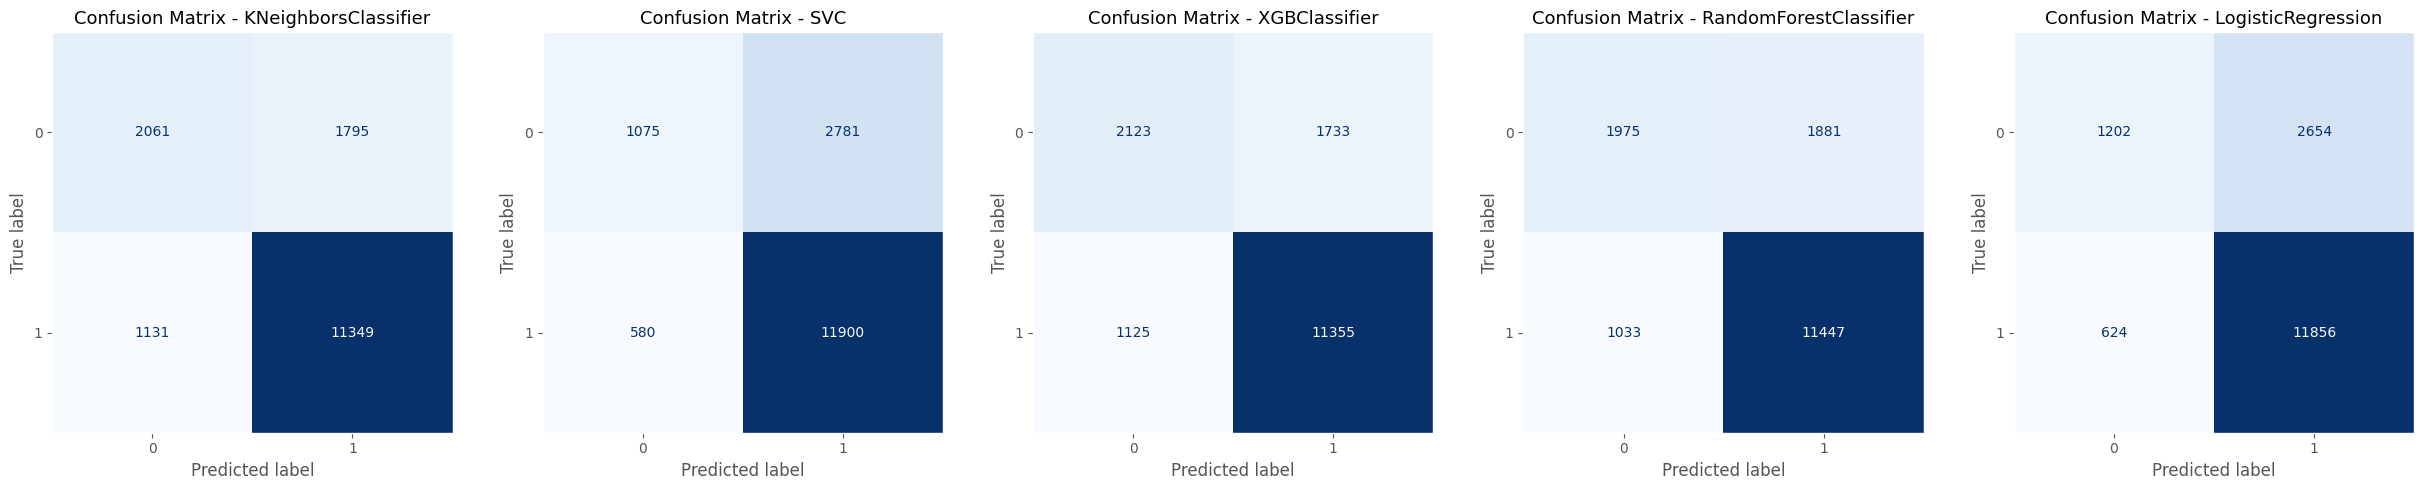

In [ ]:
# display confusion matrx
fig, axes = plt.subplots(1,
                         len(results),
                         figsize= (5 * len(results), 5))
for m in range(len(results)):
  plt.rcParams['axes.grid'] = False
  best_model = results[m]['best_model']
  model_name = results[m]['model']
  y_test_pred = best_model.predict(X_test)
  ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap = 'Blues',
    ax = axes[m],
    colorbar=False
  )
  axes[m].set_title(f'Confusion Matrix - {model_name}', fontsize=13)
  plt.tight_layout()
  plt.savefig('images/model/confusion_matrix_models.png')

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionar

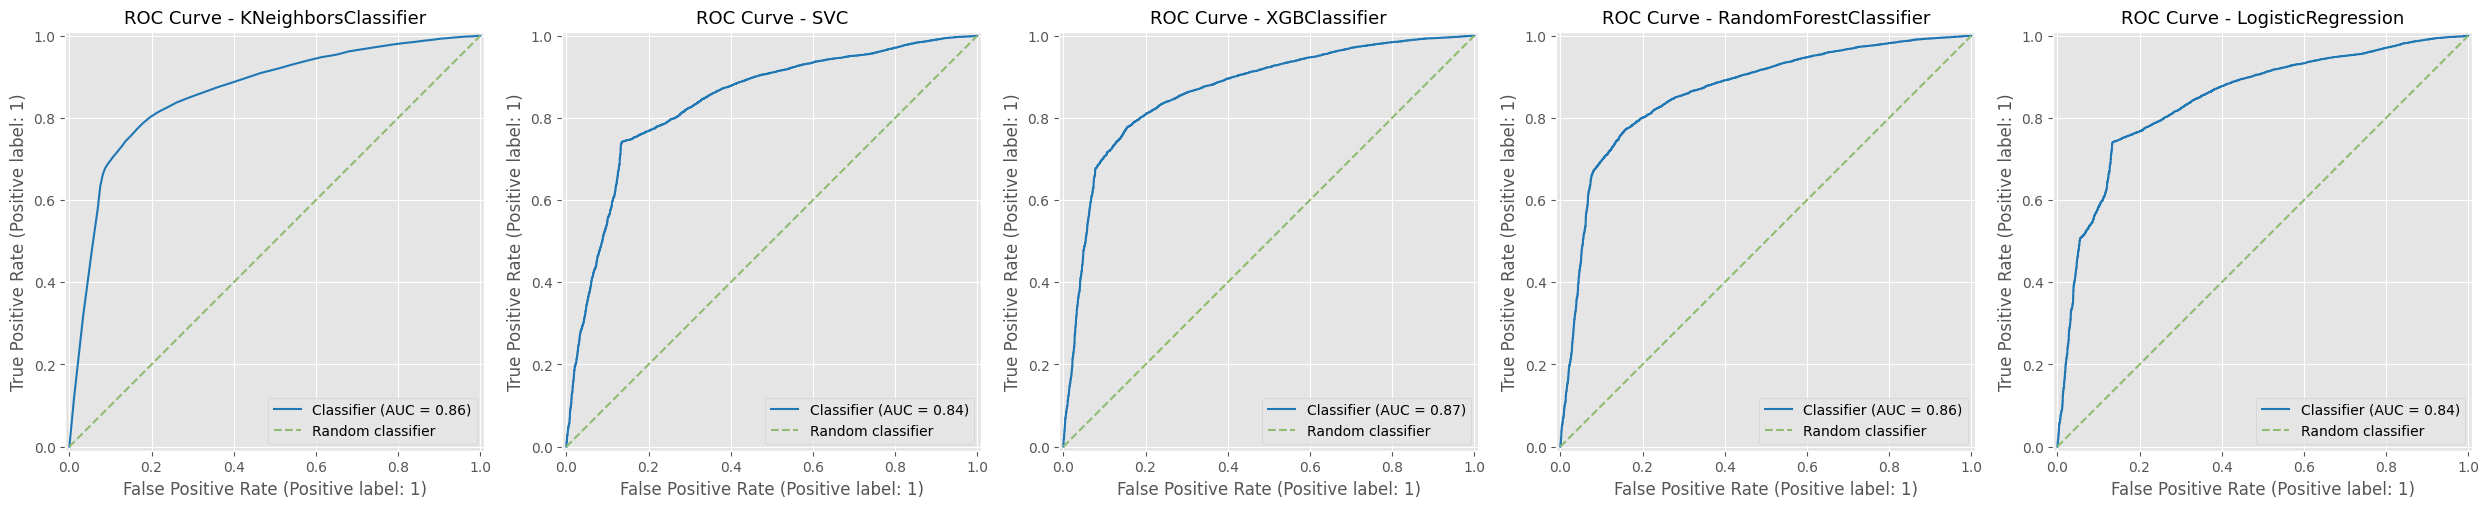

<Figure size 640x480 with 0 Axes>

In [ ]:
# display AUC curve

plt.style.use('ggplot')

fig, axes = plt.subplots(
    1,
    len(results),
    figsize=(5 * len(results), 5)
)

for m in range(len(results)):

    best_model = results[m]['best_model']
    model_name = results[m]['model']

    if hasattr(best_model, 'predict_proba'):
        y_test_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_test_score = best_model.decision_function(X_test)

    auc_score = roc_auc_score(
        y_test,
        y_test_score
    )

    RocCurveDisplay.from_predictions(
        y_test,
        y_test_score,
        color='tab:blue',
        ax=axes[m]
    )
    axes[m].plot(
        [0,1],
        [0,1],
        linestyle = "--",
        color="#8FBC70",
        label="Random classifier"
    )
    axes[m].set_title(f"ROC Curve - {model_name}", fontsize=13)
    axes[m].legend(loc="lower right")
plt.tight_layout()
plt.show()
plt.savefig('images/model/auc_roc_curve_models.png')

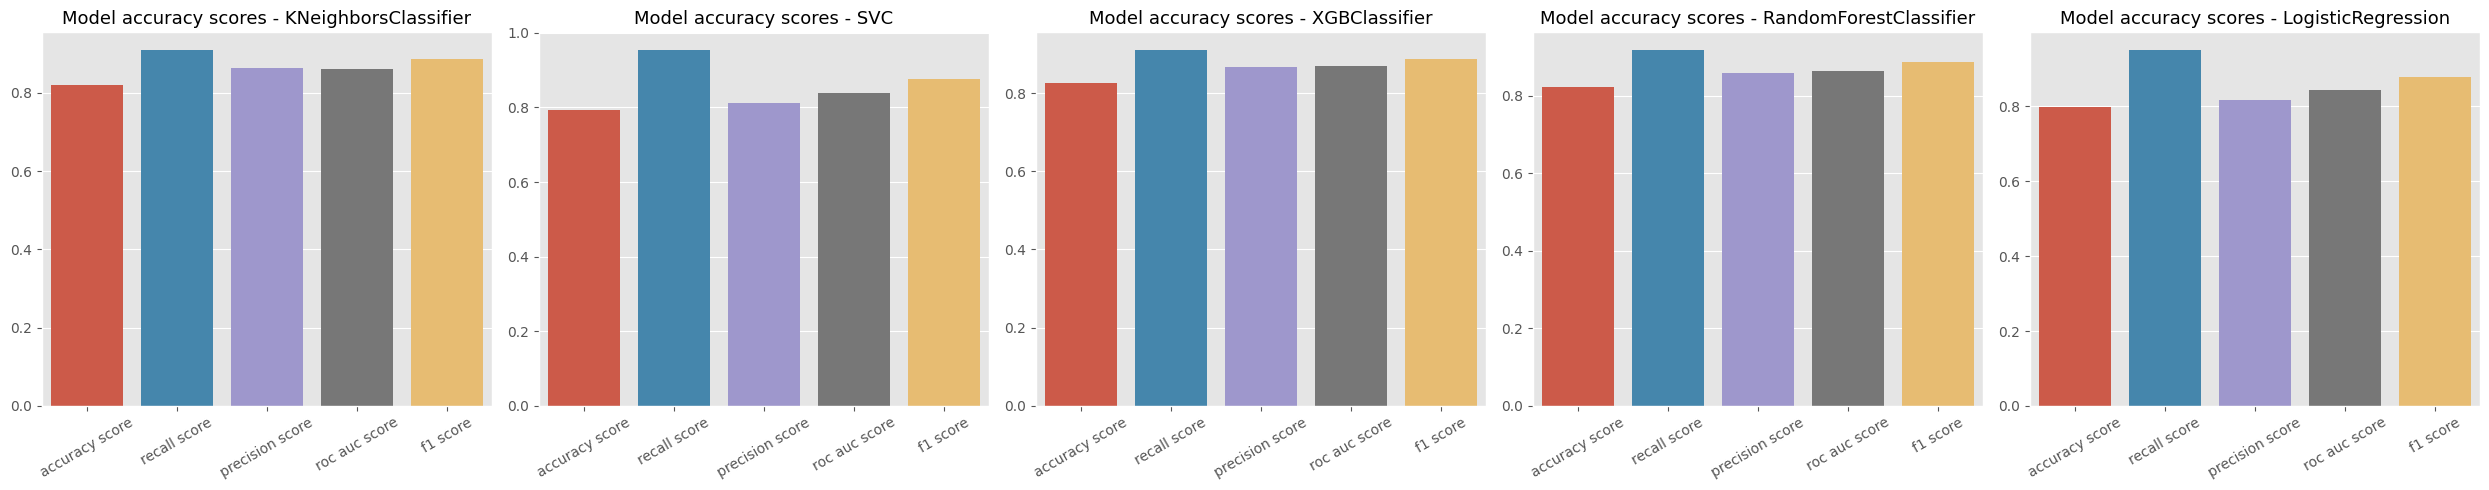

<Figure size 640x480 with 0 Axes>

In [583]:

# roc-auc, precsion, recall, f1 scores
accuracy_df = pd.DataFrame(accuracies)
fig, axes = plt.subplots(
  1,
  len(accuracies),
  figsize = (5 * len(accuracies), 5)
  )
for i in range(len(accuracies)):
  sns.barplot(
    x = accuracy_df.iloc[i].index[1:6],
    y = accuracy_df.iloc[i].values[1:6],
    hue = accuracy_df.iloc[i].index[1:6],
    ax = axes[i]
  )
  axes[i].set_title(f'Model accuracy scores - {accuracy_df.iloc[i].values[0]}', fontsize = 13)
  axes[i].tick_params(axis="x", rotation=30)
  axes[i].set_xlabel("")
plt.tight_layout()
plt.show()
plt.savefig('images/model/accuracy_scors.png')

### Feature importance

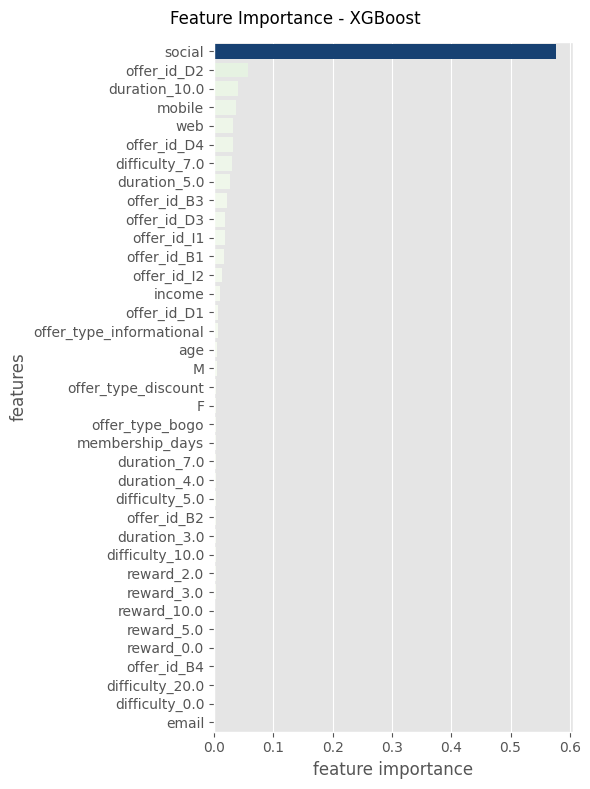

<Figure size 640x480 with 0 Axes>

In [584]:
# feature importances of xgboost
xgboost_feature_importance = pd.DataFrame({
'features': X_train.columns,
'feature importance': results[2]['best_model'].feature_importances_
}).sort_values(by = 'feature importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize = (6,8))
sns.barplot(
  data = xgboost_feature_importance,
  x = 'feature importance',
  y = 'features',
  hue = 'feature importance',
  palette = 'GnBu',
  legend = False,
  ax = ax
)
plt.suptitle('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()
plt.savefig('images/model/feature_importance_xgboost.png')